# Inverses and Invertibility

This notebook accompanies Lecture 02, **Inverses and Invertibility**. It is a computational companion—not a second version of the lecture. Use the slides for the mathematical ideas and this notebook to test invertibility, compute inverses when the inverse itself is needed, compare singular-system outcomes, and interpret two applications.

We use three complementary tools:

- **SymPy** for exact row reduction, inverses, null vectors, and symbolic solution families.
- **NumPy** for floating-point solves and residual checks.
- **Matplotlib** for comparing covariance and precision patterns.

**Working habit:** predict each result before running the next code cell, then check the result against the defining matrix equations.

## Run the notebook locally or in Colab

Use Jupyter with the `qmcpy` environment, or open a private working copy in Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH332Fall2026/blob/main/notebooks/demonstrations/02-inverses-and-invertibility.ipynb)

In Colab, run the setup cell below once and then continue in order. It installs the course's recorded `classlib` version. Colab does not save changes back to the course repository; use **File → Save a copy in Drive** if you want to keep your work.

In [1]:
from pathlib import Path
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib; this may take a minute …")
    course_checkout = Path("/content/MATH332Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH332Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "submodule", "update", "--init", "classlib",
        ],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", str(course_checkout / "classlib")],
        check=True,
    )
    print("Colab setup complete.")

In [2]:
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from sympy import Matrix

import classlib as cl
from classlib.nbviz import show_augmented, show_mat

%matplotlib inline

cl.nbviz.init(use_tex=False)
colors = cl.nbviz.TOL_BRIGHT
sp.init_printing()
np.set_printoptions(precision=6, suppress=True)

## 1. Use pivots to test invertibility

Return to the recurring three-equation matrix from Lecture 01:

$$
\mathsf{A}=
\begin{bmatrix}
1&2&-1\\
2&-1&1\\
3&1&2
\end{bmatrix},\qquad
\boldsymbol{b}=
\begin{bmatrix}2\\-3\\1\end{bmatrix}.
$$

A square matrix is invertible exactly when its row-reduced form has a pivot in every row and column. Row-reduce $[\,\mathsf{A}\mid\boldsymbol{b}\,]$ so the same operations act on $\boldsymbol{b}$. Predict whether the left block becomes $\mathsf{I}$ and which solution appears in the right column.

the original system [A | b]:


<IPython.core.display.Math object>

reduced row echelon form [I | x]:


<IPython.core.display.Math object>

pivot columns of A: (1, 2, 3)
left block is I, so A is invertible: True
unique solution read from the right column:


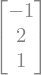

In [3]:
A = Matrix([
    [1,  2, -1],
    [2, -1,  1],
    [3,  1,  2],
])
b = Matrix([2, -3, 1])

print("the original system [A | b]:")
show_augmented(A, b)

augmented_rref, augmented_pivots = A.row_join(b).rref()
coefficient_rref = augmented_rref[:, :A.cols]
solution_from_rref = augmented_rref[:, A.cols:]
coefficient_pivots = tuple(
    column + 1 for column in augmented_pivots if column < A.cols
)

print("reduced row echelon form [I | x]:")
show_augmented(coefficient_rref, solution_from_rref)
print("pivot columns of A:", coefficient_pivots)
print("left block is I, so A is invertible:",
      coefficient_rref == sp.eye(A.rows))
print("unique solution read from the right column:")
show_mat(solution_from_rref)

### Reduce beside the identity

Gauss–Jordan reduction applies the same row operations to both blocks of $[\,\mathsf{A}\mid\mathsf{I}\,]$. When the left block becomes $\mathsf{I}$, the right block is $\mathsf{A}^{-1}$.

This is the appropriate calculation when the inverse itself is the object of interest. For merely solving one or a few systems, solve directly instead.

start with [A | I]:


<IPython.core.display.Math object>

Gauss–Jordan result [I | A^{-1}]:


<IPython.core.display.Math object>

verify both inverse orders:


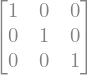

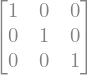

A^{-1} agrees with SymPy's inverse: True


In [4]:
identity = sp.eye(A.rows)
augmented_for_inverse = A.row_join(identity)
reduced_augmented, inverse_pivots = augmented_for_inverse.rref()
A_inverse = reduced_augmented[:, A.cols:]

print("start with [A | I]:")
show_augmented(A, identity)
print("Gauss–Jordan result [I | A^{-1}]:")
show_augmented(reduced_augmented[:, :A.cols], A_inverse)

print("verify both inverse orders:")
show_mat(A_inverse * A, A * A_inverse)
print("A^{-1} agrees with SymPy's inverse:", A_inverse == A.inv())

### Compare three solution routes

The augmented RREF already gave the unique solution. Mathematically, $\boldsymbol{x}=\mathsf{A}^{-1}\boldsymbol{b}$ as well. Computationally, use a direct solve when the inverse is not otherwise needed. Compare all three exact routes and check the residual against the original system.

solution from RREF, A^{-1} b, direct solve, and residual A x - b:


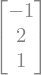

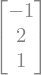

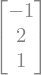

all three solution routes agree: True


In [5]:
solution_from_inverse = A_inverse * b
solution_from_solve = A.LUsolve(b)

print("solution from RREF, A^{-1} b, direct solve, and residual A x - b:")
show_mat(
    solution_from_rref,
    solution_from_inverse,
    solution_from_solve,
    A * solution_from_solve - b,
)
print("all three solution routes agree:",
      solution_from_rref == solution_from_inverse == solution_from_solve)

## 2. A missing pivot reveals information loss

### Find a nonzero null direction

Consider the singular matrix

$$
\mathsf{S}=\begin{bmatrix}1&2\\2&4\end{bmatrix}.
$$

Its second row is twice its first, so one pivot is missing. Predict a nonzero vector $\boldsymbol{z}$ satisfying $\mathsf{S}\boldsymbol{z}=\boldsymbol{0}$.

S, its reduced form, and one nonzero null vector z:


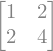

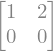

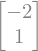

pivot columns: (0,)
S z:


In [6]:
S = Matrix([[1, 2], [2, 4]])
S_rref, S_pivots = S.rref()
null_direction = S.nullspace()[0]

print("S, its reduced form, and one nonzero null vector z:")
show_mat(S, S_rref, null_direction)
print("pivot columns:", S_pivots)
print("S z:")
show_mat(S * null_direction)

### The right-hand side decides between none and infinitely many

Compare

$$
\boldsymbol{b}_{\mathrm{compatible}}=\begin{bmatrix}3\\6\end{bmatrix},\qquad
\boldsymbol{b}_{\mathrm{incompatible}}=\begin{bmatrix}3\\7\end{bmatrix}.
$$

A singular square matrix can never give exactly one solution. Predict which right-hand side is reachable.

compatible system in reduced form:


<IPython.core.display.Math object>

solution set:


incompatible system in reduced form:


<IPython.core.display.Math object>

solution set:


one parameterized family and its symbolic residual:


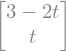

In [7]:
x1, x2, t = sp.symbols("x_1 x_2 t")
variables = (x1, x2)
b_compatible = Matrix([3, 6])
b_incompatible = Matrix([3, 7])

for name, right_side in [
    ("compatible", b_compatible),
    ("incompatible", b_incompatible),
]:
    reduced = S.row_join(right_side).rref()[0]
    print(f"{name} system in reduced form:")
    show_augmented(reduced[:, :-1], reduced[:, -1])
    print("solution set:")
    display(sp.linsolve((S, right_side), variables))

particular_solution = Matrix([3, 0])
solution_family = particular_solution + t * null_direction
print("one parameterized family and its symbolic residual:")
show_mat(solution_family, sp.simplify(S * solution_family - b_compatible))

## 3. Undo products in reverse order

For invertible matrices $\mathsf{F}$ and $\mathsf{G}$,

$$
(\mathsf{F}\mathsf{G})^{-1}=\mathsf{G}^{-1}\mathsf{F}^{-1}.
$$

The rightmost factor acts first, so it must be undone last. Predict whether $\mathsf{F}^{-1}\mathsf{G}$ and $\mathsf{G}\mathsf{F}^{-1}$ will agree in the example below.

(F G)^{-1}, G^{-1} F^{-1}, and their check against F G:


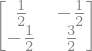

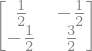

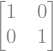

reverse-order rule verified: True
F^{-1} G and G F^{-1}:


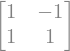

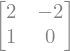

the two possible 'quotient' orders agree: False


In [8]:
F = Matrix([[1, 1], [0, 1]])
G = Matrix([[2, 0], [1, 1]])
product_inverse = (F * G).inv()
reverse_order = G.inv() * F.inv()

print("(F G)^{-1}, G^{-1} F^{-1}, and their check against F G:")
show_mat(product_inverse, reverse_order, (F * G) * reverse_order)
print("reverse-order rule verified:", product_inverse == reverse_order)

print("F^{-1} G and G F^{-1}:")
show_mat(F.inv() * G, G * F.inv())
print("the two possible 'quotient' orders agree:", F.inv() * G == G * F.inv())

## 4. Choose the least computation

NumPy's `np.linalg.solve(A, b)` solves a square nonsingular system directly. It also accepts a matrix of several right-hand sides, one per column. Form `np.linalg.inv(A)` only when the full inverse or response map is actually needed.

The next cell compares the answers and residuals. Agreement does not make explicit inversion the preferred routine solve.

one direct numerical solution: [-1.  2.  1.]
residual 2-norm: 1.2560739669470201e-15
three right-hand sides solved together:


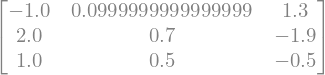

maximum residual over all right-hand sides: 8.881784197001252e-16
agreement with inverse multiplication: True


In [9]:
A_np = np.array(A, dtype=float)
b_np = np.array(b, dtype=float).ravel()
B_np = np.column_stack((
    b_np,
    np.array([1.0, 0.0, 2.0]),
    np.array([-2.0, 4.0, 1.0]),
))

x_direct = np.linalg.solve(A_np, b_np)
X_direct = np.linalg.solve(A_np, B_np)
A_inverse_np = np.linalg.inv(A_np)
X_from_inverse = A_inverse_np @ B_np

print("one direct numerical solution:", x_direct)
print("residual 2-norm:", np.linalg.norm(A_np @ x_direct - b_np))
print("three right-hand sides solved together:")
show_mat(X_direct)
print("maximum residual over all right-hand sides:",
      np.max(np.abs(A_np @ X_direct - B_np)))
print("agreement with inverse multiplication:",
      np.allclose(X_direct, X_from_inverse))

## 5. Leontief production: solve or build a response map

### Solve one demand forecast

The two-sector model in the slides uses

$$
\mathsf{C}=\begin{bmatrix}0.20&0.10\\0.30&0.25\end{bmatrix},\qquad
\boldsymbol{d}=\begin{bmatrix}72\\30\end{bmatrix},
$$

and solves

$$
(\mathsf{I}-\mathsf{C})\boldsymbol{x}=\boldsymbol{d}.
$$

Predict the gross production vector $\boldsymbol{x}$ and then check that internal demand plus external demand equals total production.

I - C, gross production x, and internal demand C x:


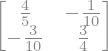

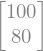

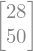

check C x + d = x: True
all gross production entries are nonnegative: True
exact and decimal response maps (I - C)^{-1}:


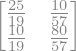

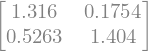

In [10]:
C = Matrix([
    [sp.Rational(1, 5),  sp.Rational(1, 10)],
    [sp.Rational(3, 10), sp.Rational(1, 4)],
])
demand = Matrix([72, 30])
balance_matrix = sp.eye(2) - C
production = balance_matrix.LUsolve(demand)
response_map = balance_matrix.inv()
internal_demand = C * production

print("I - C, gross production x, and internal demand C x:")
show_mat(balance_matrix, production, internal_demand)
print("check C x + d = x:", internal_demand + demand == production)
print("all gross production entries are nonnegative:",
      all(value >= 0 for value in production))

print("exact and decimal response maps (I - C)^{-1}:")
show_mat(response_map, response_map.evalf(4))

### Interpret the response-map columns

The first column of $(\mathsf{I}-\mathsf{C})^{-1}$ is the production response to one additional unit of external demand in sector 1; the second column gives the corresponding response for sector 2. This is when the inverse itself has a useful interpretation.

response to one added unit of demand in sector 1 and sector 2:


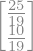

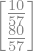

multiplying the map by the original demand recovers production: True


In [11]:
print("response to one added unit of demand in sector 1 and sector 2:")
show_mat(response_map[:, 0], response_map[:, 1])
print("multiplying the map by the original demand recovers production:",
      response_map * demand == production)

## 6. Covariance and precision can have different zero patterns

### Compute and compare the matrices

For the covariance matrix

$$
\boldsymbol{\Sigma}=
\begin{bmatrix}1&1&0\\1&2&1\\0&1&2\end{bmatrix},
$$

the precision matrix is $\mathsf{Q}=\boldsymbol{\Sigma}^{-1}$. Compute $\mathsf{Q}$ exactly, verify both inverse orders, and compare the $(1,3)$ entries.

covariance, precision, Sigma Q, and Q Sigma:


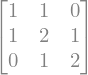

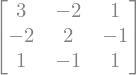

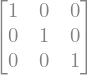

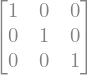

Sigma[1,3] in mathematical indexing: 0
Q[1,3] in mathematical indexing: 1


In [12]:
Sigma = Matrix([
    [1, 1, 0],
    [1, 2, 1],
    [0, 1, 2],
])
Q_precision = Sigma.inv()

print("covariance, precision, Sigma Q, and Q Sigma:")
show_mat(Sigma, Q_precision, Sigma * Q_precision, Q_precision * Sigma)
print("Sigma[1,3] in mathematical indexing:", Sigma[0, 2])
print("Q[1,3] in mathematical indexing:", Q_precision[0, 2])

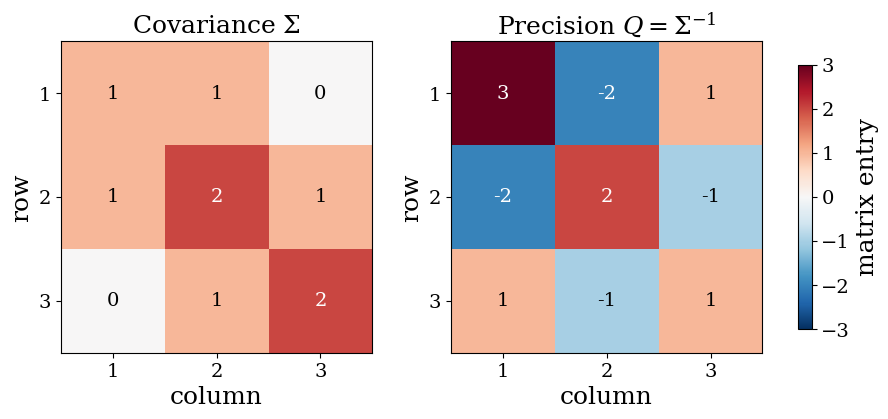

In [13]:
def annotated_matrix_plot(matrix, title, ax, limit):
    values = np.array(matrix, dtype=float)
    image = ax.imshow(values, cmap="RdBu_r", vmin=-limit, vmax=limit)
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            text_color = "white" if abs(values[row, col]) > limit / 2 else "black"
            ax.text(col, row, f"{values[row, col]:g}",
                    ha="center", va="center", color=text_color, fontsize=14)
    ax.set_title(title)
    ax.set_xticks(range(values.shape[1]), labels=range(1, values.shape[1] + 1))
    ax.set_yticks(range(values.shape[0]), labels=range(1, values.shape[0] + 1))
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    return image

plot_limit = max(
    np.max(np.abs(np.array(Sigma, dtype=float))),
    np.max(np.abs(np.array(Q_precision, dtype=float))),
)
fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
image = annotated_matrix_plot(Sigma, r"Covariance $\Sigma$", axes[0], plot_limit)
annotated_matrix_plot(Q_precision, r"Precision $Q=\Sigma^{-1}$", axes[1], plot_limit)
fig.colorbar(image, ax=axes, shrink=0.85, label="matrix entry")
plt.show()

### Solve when only $\mathsf{Q}\boldsymbol{r}$ is needed

If a calculation needs $\boldsymbol{\alpha}=\mathsf{Q}\boldsymbol{r}$, solve $\boldsymbol{\Sigma}\boldsymbol{\alpha}=\boldsymbol{r}$ rather than forming the whole precision matrix merely for that product.

alpha from a direct solve, alpha from Q r, and the residual:


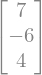

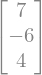

the two routes agree: True


In [14]:
r = Matrix([1, -1, 2])
alpha_from_solve = Sigma.LUsolve(r)
alpha_from_precision = Q_precision * r

print("alpha from a direct solve, alpha from Q r, and the residual:")
show_mat(
    alpha_from_solve,
    alpha_from_precision,
    Sigma * alpha_from_solve - r,
)
print("the two routes agree:", alpha_from_solve == alpha_from_precision)

## 7. Experiments

Try these after the main notebook runs successfully:

1. Replace one entry of $\mathsf{A}$ by zero. Does the pivot test change? If the matrix remains invertible, recompute its inverse and verify both orders.
2. Find another right-hand side compatible with the singular matrix $\mathsf{S}$ and write its full parameterized solution family.
3. Choose two invertible $2\times2$ matrices and verify the reverse-order product rule. Then find an example where $\mathsf{F}^{-1}\mathsf{G}\ne\mathsf{G}\mathsf{F}^{-1}$.
4. Change `demand_experiment` below and interpret the new production plan. Which response-map column matters more?
5. Change one off-diagonal entry of $\boldsymbol{\Sigma}$ while keeping it symmetric. Check invertibility before computing a new precision matrix.

external demand and required gross production:


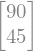

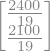

balance residual (I - C)x - d:


In [15]:
# EDITABLE INPUT: change the external demand, then interpret the result.
demand_experiment = Matrix([90, 45])
production_experiment = balance_matrix.LUsolve(demand_experiment)

print("external demand and required gross production:")
show_mat(demand_experiment, production_experiment)
print("balance residual (I - C)x - d:")
show_mat(balance_matrix * production_experiment - demand_experiment)

## 8. What to retain

- A square matrix is invertible exactly when row reduction finds a pivot in every row and column.
- Gauss–Jordan reduction of $[\,\mathsf{A}\mid\mathsf{I}\,]$ computes $\mathsf{A}^{-1}$ when the inverse itself is needed.
- A singular square matrix has a nonzero null direction; depending on the right-hand side, a system has no solutions or infinitely many.
- Products are undone in reverse order: $(\mathsf{F}\mathsf{G})^{-1}=\mathsf{G}^{-1}\mathsf{F}^{-1}$.
- Solve directly for one or a few right-hand sides; form an inverse when the response map itself matters.
- In applications, interpret and check the result: Leontief production must balance demand, while covariance and precision can reveal different relationship patterns.

Use computation to expose structure and verify reasoning—not to replace the mathematical argument in the slides.

In [16]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 13.9 sec.
